## i. Perkenalan

Nama : Ananda Karnia Amalya

Role : Data Analyst

Project ini bertujuan untuk menganalisis perilaku belanja pelanggan berdasarkan dataset shopping behavior untuk memberikan rekomendasi strategi peningkatan penjualan.

## ii. Identifikasi Masalah

### <b>Latar Belakang</b>

Dalam operasional bisnis ritel, efisiensi pengelolaan stok merupakan faktor krusial dalam menjaga profitabilitas. Penumpukan barang yang kurang diminati  sering kali menjadi beban karena menimbulkan biaya penyimpanan tambahan (holding cost) dan risiko stok mati (deadstock). Oleh karena itu, diperlukan analisis berbasis data untuk memahami perilaku belanja pelanggan dan tren pasar, sehingga dapat dirancang strategi promosi yang lebih efektif dalam mengosongkan gudang sekaligus meningkatkan pendapatan.

### <b>Tujuan</b>

Menargetkan peningkatan penjualan sebesar 20% dalam 3 bulan pada kategori produk yang kurang diminati melalui strategi promosi yang efektif dan tepat sasaran.

### <b> Problem Breakdown </b>

Apa saja kategori produk yang memiliki volume penjualan di bawah rata-rata keseluruhan?

Siapa profil pelanggan (berdasarkan gender dan kelompok usia) yang paling jarang melakukan pembelian pada kategori barang yang kurang diminati tersebut?

Di lokasi (State/Wilayah) mana penjualan kategori barang tersebut menunjukkan angka terendah?

Kapan (pada musim atau periode apa) terjadi penurunan drastis pada penjualan kategori barang tersebut?

Mengapa kategori tersebut kurang diminati jika dikaitkan dengan rata-rata skor ulasan (Review Rating) pelanggan?

Bagaimana efektivitas penggunaan promo saat ini terhadap jumlah nilai pembelian (Purchase Amount)?

### <b>SMART (Specific, Measurable, Achievable, Relevant, Time-bound):</b>

Specific: Meningkatkan volume penjualan pada kategori produk dengan performa di bawah rata-rata (seperti kategori Outerwear).

Measurable: Mencapai peningkatan total penjualan sebesar 20% untuk kategori tersebut (atau peningkatan rating rata-rata produk).

Achievable: Mengoptimalkan strategi pemasaran melalui promo Buy One Get One (BOGO) dan diskon khusus berdasarkan analisis segmen pelanggan.

Relevant: Mengurangi penumpukan stok (deadstock) untuk menekan biaya penyimpanan dan meningkatkan margin keuntungan.

Time-bound: Target ini dicapai dalam kurun waktu 3 bulan setelah strategi diimplementasikan.

### <b>Targetnya</b>

Pemilik bisnis, tim marketing atau manager operasional.

## iii. Data Loading

https://www.kaggle.com/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset

In [4]:
!pip install pandas matplotlib seaborn scipy

In [5]:
import pandas as pd
import matplotlib.pyplot as plt #digunakan untuk membuat visualisasi
import seaborn as sns # digunakan membuat visualisasi
import scipy.stats as stats
from scipy.stats import ttest_ind

In [6]:
data = pd.read_csv('shopping_behavior_updated.csv')
data.head(11) # memanggil 10 data dimulai dari angka 0

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


Langkah pertama adalah memuat dataset untuk memahami struktur data awal dan memastikan tipe data setiap kolom sudah sesuai.

In [7]:
df_clean = data.copy()

## iv. Data Cleaning

### Removing Unnecessary Columns

In [29]:
df_clean.drop(columns=['Customer ID'], inplace=True)

Kolom `Customer ID` dihapus karena tidak memiliki kontribusi terhadap analisis dan hanya berfungsi sebagai identifier unik untuk setiap pelanggan.

### Data Type Validation

In [8]:
df_clean.dtypes

Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

Melakukan validasi tipe data pada setiap kolom untuk memastikan konsistensi dan kesiapan data sebelum dilakukan proses analisis.

### Data Duplicate

In [9]:
duplicates = df_clean.duplicated() 
duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
3895    False
3896    False
3897    False
3898    False
3899    False
Length: 3900, dtype: bool

Hasil pengecekan menunjukkan False, yang berarti tidak ditemukan adanya data duplikat dalam dataset ini. Dengan demikian, setiap baris data bersifat unik dan valid untuk diproses lebih lanjut.

### Missing Value

In [10]:
missing_values = df_clean.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing_values)

Jumlah missing value per kolom:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


Berdasarkan hasil pengecekan di atas, sistem menunjukkan angka 0, yang berarti dataset ini bersih dari data duplikat dan siap untuk diproses ke tahap selanjutnya.

### Pengecekan Outlier

In [11]:
# cek missing
print(df_clean.isnull().sum())

# cek duplikat
print(df_clean.duplicated().sum())

# contoh handling outlier (opsional)
Q1 = df_clean['Purchase Amount (USD)'].quantile(0.25)
Q3 = df_clean['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[(df_clean['Purchase Amount (USD)'] >= Q1 - 1.5*IQR) &
                    (df_clean['Purchase Amount (USD)'] <= Q3 + 1.5*IQR)]

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64
0


Terlihat bahwa pada setiap kolom hasilnya 0 yang artinya tidak  data yang aneh atau tidak normal pada dataset ini.

### Standardization & Consistency

In [12]:
#Memastikan teks konsisten (lowercase dan menghapus spasi di awal/akhir)
cols_to_check = ['Category', 'Item Purchased', 'Location', 'Color', 'Season']

for col in cols_to_check:
    data[col] = df_clean[col].str.strip().str.title() #Mengubah ke format agar rapi

#Menampilkan nilai unik dari kolom Category untuk verifikasi
print(f"Kategori yang tersedia: {data['Category'].unique()}")

Kategori yang tersedia: <StringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str



Pembagian kategori ini akan digunakan sebagai dasar dalam analisis lebih lanjut untuk mengidentifikasi performa masing-masing kategori dalam hal jumlah transaksi maupun nilai pembelian

### Pengelompokan Usia

Hal ini dilakukan untuk mempermudah jalannya proses analisis karena rentang usia pembeli yang sangat bervariasi sehingga dilakukan pengelompokan.

In [13]:
bins = [0, 18, 30, 50, 100]
labels = ['Teenager/Young Adult', 'Adult', 'Middle-Aged', 'Senior']

df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, right=False)

print(df_clean['Age_Group'].value_counts())

Age_Group
Senior                  1559
Middle-Aged             1463
Adult                    878
Teenager/Young Adult       0
Name: count, dtype: int64


Rentang Umur	Notasi	Kategori

0 ≤ umur < 18	[0, 18]	Teenager/Young Adult

18 ≤ umur < 30	[18, 30]	Adult

30 ≤ umur < 50	[30, 50]	Middle-Aged

50 ≤ umur < 100	[50, 100]	Senior

Setelah dilakukan pengelompokan dapat terlihat bahwa yang paling sering berbelanja merupakan kategori senior yang kemudian disusul dnegan middle aged.

## v. Analisis Dan Perhitungan

### Apa saja kategori produk yang memiliki volume penjualan di bawah rata-rata keseluruhan?

C:\Users\User\AppData\Local\Temp\ipykernel_18252\2341914833.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


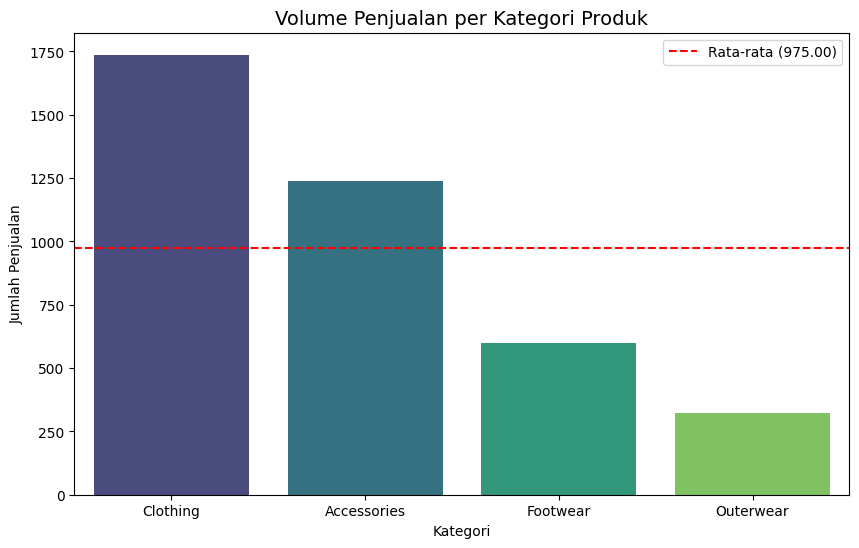

In [14]:
# Menghitung jumlah penjualan per kategori
category_counts = df_clean['Category'].value_counts()
avg_sales = category_counts.mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.axhline(avg_sales, color='red', linestyle='--', label=f'Rata-rata ({avg_sales:.2f})')

plt.title('Volume Penjualan per Kategori Produk', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Penjualan')
plt.legend()
plt.show()

Berdasarkan grafik di atas, terdapat dua kategori yang ada dibawah rata-rata, yaitu Footwear dan  Outerwear. namun, OUtwear berada di paling bawah dari rata-rata penjualan. Hal ini mengonfirmasi bahwa Outerwear adalah kategori yang menjadi beban stok dan memerlukan intervensi promosi.

In [27]:
outerwear_items = df_clean[df_clean['Category'] == 'Outerwear']['Item Purchased'].unique()
print(outerwear_items)
df_clean[df_clean['Category'] == 'Outerwear']['Item Purchased'].value_counts()

<StringArray>
['Coat', 'Jacket']
Length: 2, dtype: str


Item Purchased
Jacket    163
Coat      161
Name: count, dtype: int64

Diketahui bahwa Outerwear ini terdiri dari dua produk 

### Siapa profil pelanggan (berdasarkan gender dan kelompok usia) yang paling jarang melakukan pembelian pada kategori barang yang kurang diminati tersebut?

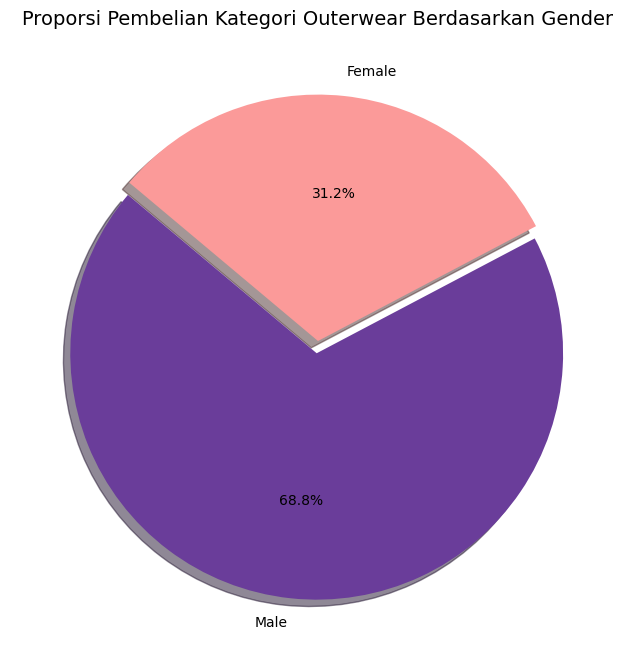

In [15]:
plt.figure(figsize=(8, 8))

low_perf_cat = df_clean[df_clean['Category'] == 'Outerwear']
# 1. Menghitung data Gender
gender_counts = low_perf_cat['Gender'].value_counts()

# 2. Membuat Pie Chart
plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', # Menampilkan persentase dengan 1 angka di belakang koma
        startangle=140, 
        colors=['#6a3d9a', '#fb9a99'], # Ungu untuk Male, Pink/Merah Muda untuk Female
        explode=(0.05, 0), # Memberikan sedikit jarak pada potongan terbesar agar lebih estetik
        shadow=True)

plt.title('Proporsi Pembelian Kategori Outerwear Berdasarkan Gender', fontsize=14)
plt.show()

DIketahui bahwa gender wanita merupakan yang paling jarang membeli outerwear perbedaan selisih ini cukup signifikan karena presentase pria 2 kali lipat lebih banyak dibanding wanita.

C:\Users\User\AppData\Local\Temp\ipykernel_18252\2878068780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')


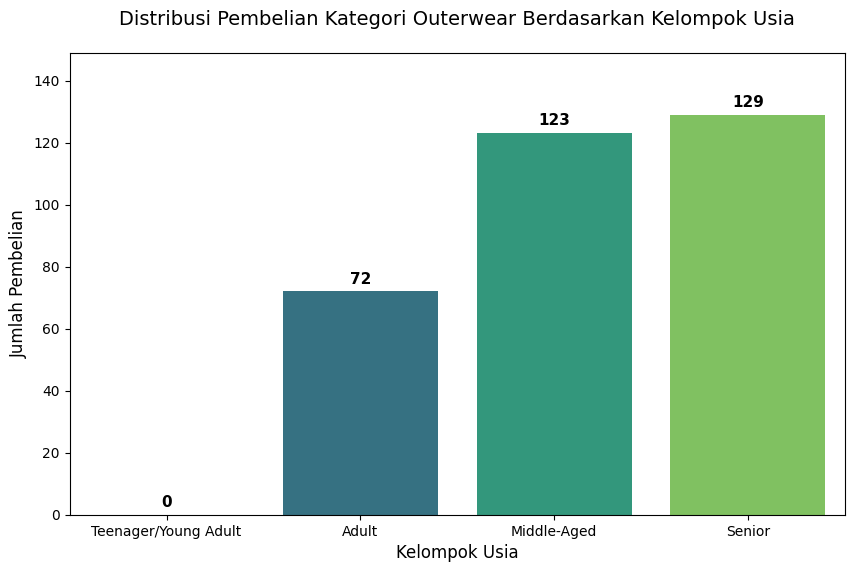

In [16]:
plt.figure(figsize=(10, 6))

# 1. Menghitung distribusi Kelompok Usia pada kategori Outerwear
# Pastikan low_perf_cat sudah difilter: low_perf_cat = df_clean[df_clean['Category'] == 'Outerwear']
age_counts = low_perf_cat['Age_Group'].value_counts().sort_index()

# 2. Membuat Bar Chart
ax = sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')

# 3. Menambahkan label angka di atas setiap batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Distribusi Pembelian Kategori Outerwear Berdasarkan Kelompok Usia', fontsize=14, pad=20)
plt.xlabel('Kelompok Usia', fontsize=12)
plt.ylabel('Jumlah Pembelian', fontsize=12)

# Memberikan ruang tambahan di atas agar angka tidak terpotong
plt.ylim(0, age_counts.max() + 20)

plt.show()

Telihat bahwa teenager/young 0 ≤ umur < 18 merupakan kelompok usia yang tidak membeli category tersebut dibanding dengan yang lainnya.

### Di lokasi (State/Wilayah) mana penjualan kategori barang tersebut menunjukkan angka terendah?

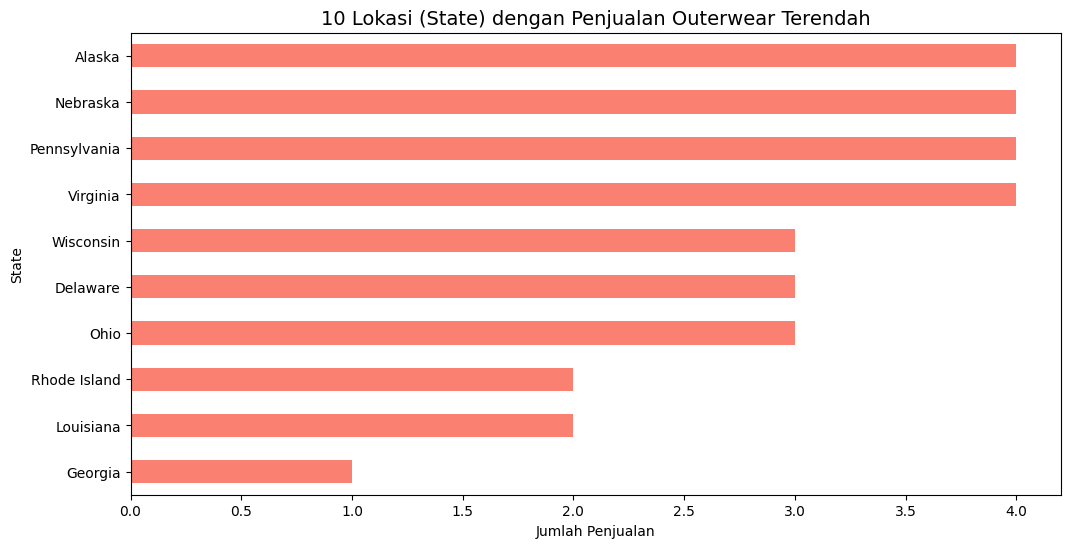

In [17]:
# Mengambil 10 State dengan penjualan terendah untuk Outerwear
state_sales = low_perf_cat['Location'].value_counts().tail(10)

plt.figure(figsize=(12, 6))
state_sales.sort_values().plot(kind='barh', color='salmon')

plt.title('10 Lokasi (State) dengan Penjualan Outerwear Terendah', fontsize=14)
plt.xlabel('Jumlah Penjualan')
plt.ylabel('State')
plt.show()

Penjualan Outerwear paling rendah berada di Georgia. hal ini sangat jauh dibanding dengan state lainnya.

### Kapan (pada musim atau periode apa) terjadi penurunan drastis pada penjualan kategori barang tersebut?

C:\Users\User\AppData\Local\Temp\ipykernel_18252\2833575235.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=low_perf_cat, x='Season', order=['Spring', 'Summer', 'Fall', 'Winter'], palette='coolwarm')


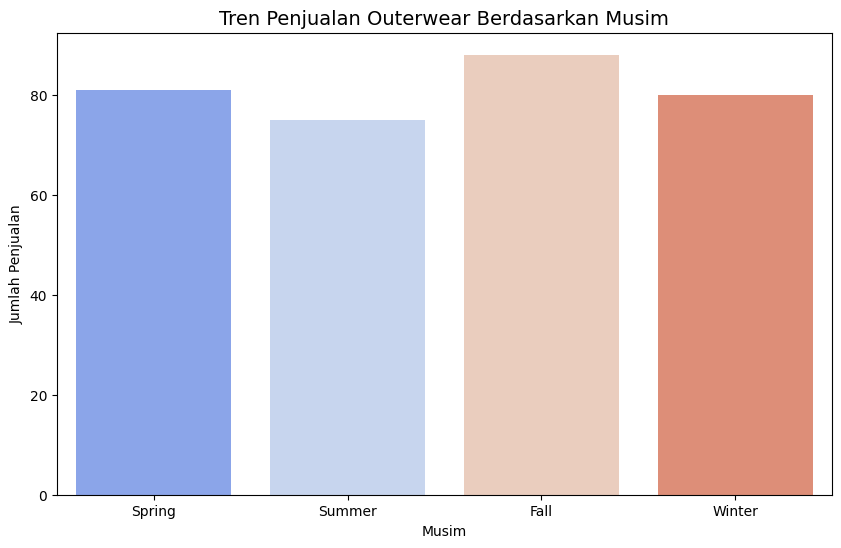

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=low_perf_cat, x='Season', order=['Spring', 'Summer', 'Fall', 'Winter'], palette='coolwarm')

plt.title('Tren Penjualan Outerwear Berdasarkan Musim', fontsize=14)
plt.xlabel('Musim')
plt.ylabel('Jumlah Penjualan')
plt.show()

Penjualan Outerwear paling rendah terjadi pada musim summer, meskipun perbedaannya tidak terlalu jauh dibandingkan musim lainnya. Hal ini tetap menunjukkan adanya pengaruh faktor musiman terhadap penjualan.

### Mengapa kategori tersebut kurang diminati jika dikaitkan dengan rata-rata skor ulasan (Review Rating) pelanggan?

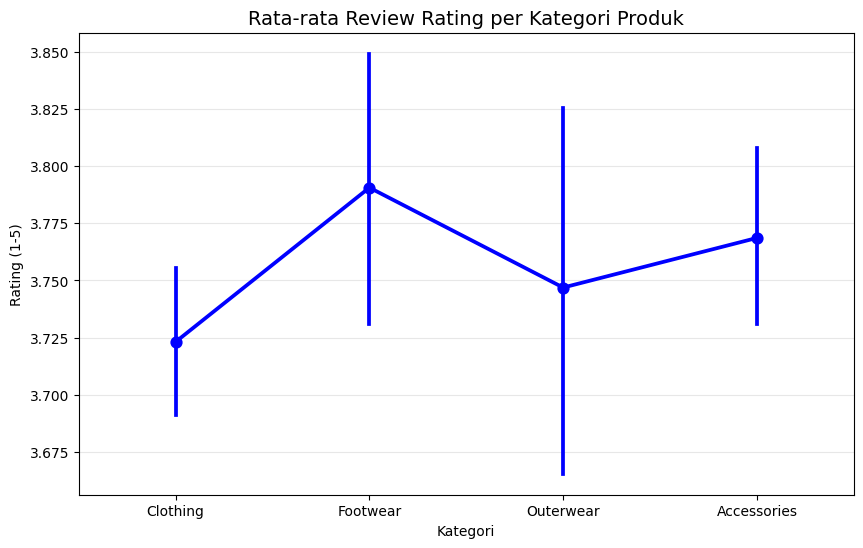

In [21]:
# Membandingkan rating rata-rata antar kategori
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_clean, x='Category', y='Review Rating', color='blue')

plt.title('Rata-rata Review Rating per Kategori Produk', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Rating (1-5)')
plt.grid(axis='y', alpha=0.3)
plt.show()

Secara keseluruhan, rating produk berada pada level cukup baik (sekitar 3.7–3.8), dengan Footwear memiliki kepuasan tertinggi, Clothing terendah sehingga perlu perbaikan, sementara Outerwear menunjukkan ketidakstabilan kualitas dan Accessories relatif konsisten.


### Bagaimana efektivitas penggunaan promo saat ini terhadap jumlah nilai pembelian (Purchase Amount)?

H0 (Null Hypothesis): Tidak terdapat perbedaan rata-rata purchase amount antara pelanggan yang menggunakan promo dan yang tidak.

H1 (Alternative Hypothesis): Terdapat perbedaan rata-rata purchase amount antara pelanggan yang menggunakan promo dan yang tidak.

In [28]:


# Pisahkan data berdasarkan promo
promo = df_clean[df_clean['Promo Code Used'] == 'Yes']['Purchase Amount (USD)']
non_promo = df_clean[df_clean['Promo Code Used'] == 'No']['Purchase Amount (USD)']

# T-Test
t_stat, p_val = ttest_ind(promo, non_promo)

print("T-Statistic:", t_stat)
print("P-Value:", p_val)

T-Statistic: -1.1113791657829266
P-Value: 0.26647372005775366


Berdasarkan hasil uji T-Test, diperoleh nilai p-value sebesar 0.266 (> 0.05). Hal ini menunjukkan bahwa tidak terdapat perbedaan yang signifikan antara purchase amount pelanggan yang menggunakan promo dan yang tidak menggunakan promo.

Dengan demikian, H0 (hipotesis nol) gagal ditolak, yang berarti promo tidak memiliki pengaruh yang signifikan terhadap nilai pembelian pelanggan dalam dataset ini.

Hal ini mengindikasikan bahwa strategi promo yang saat ini digunakan mungkin belum efektif dalam meningkatkan nilai transaksi pelanggan. Oleh karena itu, diperlukan evaluasi lebih lanjut terhadap jenis, target, maupun mekanisme promo agar dapat memberikan dampak yang lebih optimal.

Selain itu, perbedaan rata-rata yang tidak signifikan ini juga dapat menunjukkan bahwa faktor lain seperti preferensi pelanggan, kategori produk, atau lokasi kemungkinan lebih berpengaruh terhadap purchase amount dibandingkan promo.

## vi. Kesimpulan

## Kesimpulan

Berdasarkan hasil analisis yang telah dilakukan, dapat disimpulkan bahwa kategori produk dengan performa penjualan terendah adalah **Outerwear**. Temuan ini konsisten terlihat dari berbagai aspek analisis yang dilakukan.

Dari sisi pelanggan, pelanggan perempuan merupakan kelompok yang paling jarang melakukan pembelian pada kategori ini. Selain itu, pada kelompok usia 0 ≤ umur < 18 (Teenager/Young Adult), tidak ditemukan adanya transaksi untuk produk Outerwear, yang menunjukkan bahwa minat dari segmen usia tersebut sangat rendah.

Jika dilihat dari sisi waktu, penjualan Outerwear mengalami penurunan paling signifikan pada musim **summer**. Hal ini cukup masuk akal, mengingat produk dalam kategori ini didominasi oleh jaket dan coat yang kurang relevan digunakan saat cuaca panas.

Dari analisis statistik deskriptif, rating pada kategori Outerwear juga cenderung lebih bervariasi dibandingkan kategori lain. Hal ini mengindikasikan bahwa pengalaman pelanggan terhadap produk di kategori ini belum konsisten.

Sementara itu, hasil uji statistik inferensial menggunakan T-Test menunjukkan bahwa tidak terdapat perbedaan signifikan pada purchase amount antara pelanggan yang menggunakan promo dan yang tidak (p-value > 0.05). Dengan kata lain, promo yang saat ini diterapkan belum terbukti memberikan dampak yang berarti terhadap nilai pembelian.

## Rekomendasi

Berdasarkan temuan tersebut, beberapa langkah yang dapat dipertimbangkan antara lain:

- Menyesuaikan strategi penjualan berdasarkan musim, misalnya dengan memberikan diskon atau mengurangi stok Outerwear saat summer.
- Mengembangkan produk Outerwear yang lebih ringan agar tetap relevan digunakan di berbagai kondisi cuaca.
- Mengarahkan strategi pemasaran ke segmen pelanggan yang lebih potensial, seperti kelompok usia dewasa.
- Mengevaluasi kembali efektivitas promo, dan mempertimbangkan alternatif seperti bundling produk atau penawaran yang lebih personal.
- Meningkatkan kualitas produk dengan memperhatikan feedback pelanggan agar pengalaman penggunaan menjadi lebih konsisten.
